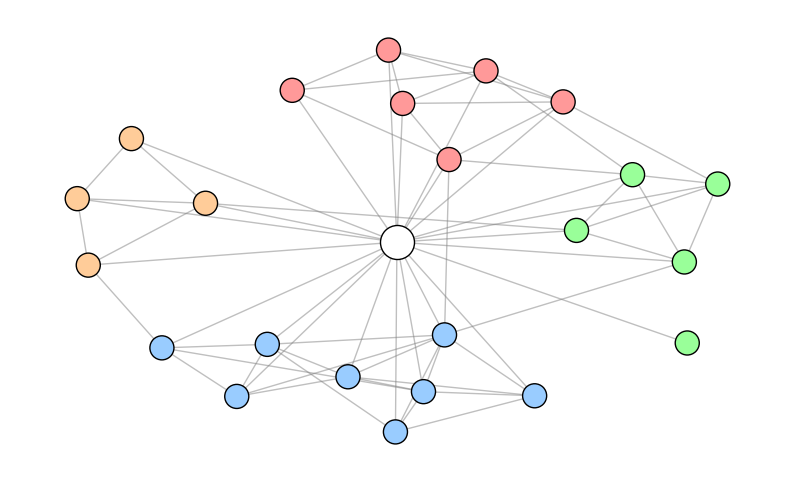

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random

def draw_ego_network():
    # 1. 建立一個空的圖
    G = nx.Graph()
    
    # 2. 定義中心節點 (Ego)
    ego_node = 'Ego'
    G.add_node(ego_node)
    
    # 3. 定義幾個社群 (Circles) 的參數
    # 格式: (社群名稱, 節點數量, 顏色)
    circles = [
        ("Family", 6, "#FF9999"),       # 紅色系
        ("CS Friends", 8, "#99CCFF"),   # 藍色系
        ("High School", 5, "#99FF99"),  # 綠色系
        ("Hiking Club", 4, "#FFCC99")   # 橘色系
    ]
    
    all_alters = []
    color_map = []
    node_sizes = []
    
    # 4. 生成節點並連線
    # 先把 Ego 的顏色與大小設定好
    node_colors_dict = {ego_node: "#FFFFFF"} # Ego 是白色
    
    for circle_name, count, color in circles:
        circle_nodes = []
        for i in range(count):
            node_name = f"{circle_name}_{i}"
            G.add_node(node_name)
            
            # Ego 連接到所有人 (這是 Ego Network 的定義)
            G.add_edge(ego_node, node_name, weight=2.0)
            
            circle_nodes.append(node_name)
            all_alters.append(node_name)
            node_colors_dict[node_name] = color
        
        # 5. 社群內部連結 (讓他們聚在一起)
        # 隨機讓同一個圈子的人互相認識
        for i in range(len(circle_nodes)):
            for j in range(i + 1, len(circle_nodes)):
                if random.random() > 0.3: # 70% 機率互相認識
                    G.add_edge(circle_nodes[i], circle_nodes[j], weight=1.0)
    
    # 6. 社群之間的重疊 (Overlaps) - 模仿原圖的關鍵
    # 隨機讓不同圈子的人產生連結
    for i in range(len(all_alters)):
        for j in range(i + 1, len(all_alters)):
            node_a = all_alters[i]
            node_b = all_alters[j]
            # 如果他們不在同一個圈子，給予較低的機率連結
            if node_a.split('_')[0] != node_b.split('_')[0]:
                if random.random() > 0.95: # 5% 機率有跨圈連結
                    G.add_edge(node_a, node_b, weight=0.5)

    # 7. 繪圖設定
    plt.figure(figsize=(10, 6))
    
    # 使用 spring_layout 模擬力學分佈，讓連結緊密的靠得近
    pos = nx.spring_layout(G, k=0.5, seed=42) 
    
    # 準備繪圖顏色列表
    colors = [node_colors_dict.get(node, "#CCCCCC") for node in G.nodes()]
    
    # 畫節點
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=300, edgecolors='black')
    
    # 畫 Ego (特別大一點，白色)
    nx.draw_networkx_nodes(G, pos, nodelist=[ego_node], node_color='white', node_size=600, edgecolors='black')
    
    # 畫邊 (線條灰色)
    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
    
    # 這裡不畫節點名稱，因為學術圖通常只標示群體
    # nx.draw_networkx_labels(G, pos, font_size=8) 

    plt.axis('off') # 關閉座標軸
    plt.show()

# 執行繪圖
draw_ego_network()